In [29]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [2]:
df = pd.read_csv('Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [32]:
df.isnull().sum()
# sns.histplot(data=df, x=df["Species"], kde=True)

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

df['Species'] = LabelEncoder().fit_transform(df['Species'])
df['Species'].unique()

array([0, 1, 2])

In [10]:
X = df.drop(columns = ['Id', 'Species'])
Y = df['Species']

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
model = GaussianNB()
model.fit(X_train_scaled, Y_train)

GaussianNB()

In [22]:
y_pred = model.predict(X_test_scaled)

In [23]:
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]


In [27]:
print("Accuracy=",accuracy_score(Y_test,y_pred))
print("Precision=",precision_score(Y_test,y_pred,average='micro'))
print("Error=",1-accuracy_score(Y_test,y_pred))
print("Recall=",recall_score(Y_test,y_pred,average='micro'))

Accuracy= 0.9666666666666667
Precision= 0.9666666666666667
Error= 0.033333333333333326
Recall= 0.9666666666666667


<Axes: >

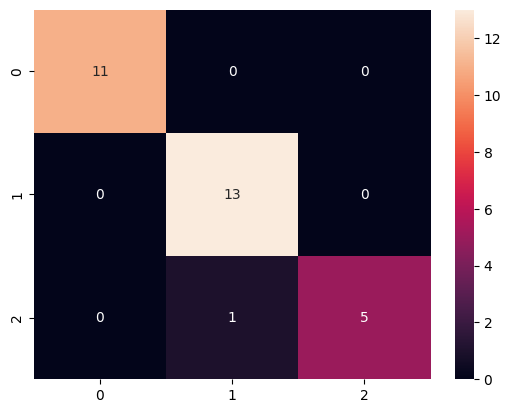

In [30]:
sns.heatmap(cm, annot=True)